# Kratos MCP Server — NACA0012 airfoil walkthrough

This notebook drives the **real** `kratos-mcp` server exactly the way an AI
assistant does: it spawns it as a subprocess over stdio using the official
[`mcp`](https://pypi.org/project/mcp/) Python client SDK, then calls tools
one by one. Every output in this notebook comes from a live run against a
compiled Kratos 10.4 build — there is no mocking anywhere.

It works through the same case as
[`docs/tutorials/naca-airfoil.md`](../docs/tutorials/naca-airfoil.md):
incompressible, laminar flow around a real NACA0012 airfoil mesh at a small
~4° angle of attack.

## Where this comes from — and what's simplified

Kratos's own examples repository has three NACA0012 validation cases, all
**transonic (Ma=0.8), compressible**, using a `CompressibleExplicit` solver
with a potential-flow bootstrap stage and boundary conditions on
conservative variables. None of that is buildable with this server today —
`add_boundary_condition` only covers `VELOCITY`/`PRESSURE`-style variables,
there's no compressible or potential-flow template, and `run_simulation` has
no multi-stage concept. This notebook reuses the real airfoil **geometry**
from that reference case (a genuine, externally-authored, ~21k-node
unstructured mesh — well beyond what this server's structured mesh
generator can produce) but drives it as a much simpler incompressible
laminar flow through the existing `fluid_transient` (Monolithic/VMS)
template. Only the shape is "the classic NACA" — the physics is
deliberately simplified to what the current toolset actually supports.

## What this notebook covers

1. Connect to the server and discover its tools/resources/prompts
2. Introspect the installation (fluid solver defaults, elements, conditions,
   variables, processes)
3. Read the `kratos://examples/naca-airfoil` resource and the
   `setup_fluid_analysis` prompt
4. Inspect/validate the bundled airfoil mesh (too large to procedurally
   generate — it ships with this server)
5. Scaffold a case from the `fluid_transient` template, overriding every
   submodelpart placeholder to match this mesh, and add the no-slip walls
6. Run the simulation as a background job (~4 minutes — this mesh is far
   bigger than the structural/thermal examples) and watch it finish
7. Post-process: VTK summaries, and a lift/drag estimate computed in plain
   Python by summing `REACTION` over the airfoil surface (this server has no
   dedicated drag/lift tool yet)
8. Render the pressure field inline, cropped to the airfoil (`results_render`
   gained a `crop_bounds` parameter for exactly this — a small body in a
   huge far-field domain is otherwise an invisible speck) and animate its
   evolution (`results_animate`)
9. A sanity check against thin-airfoil theory

## Requirements

- A working Kratos installation with `FluidDynamicsApplication` compiled.
- The `viz` extra for the rendering steps: `uv sync --extra viz`.
- A Jupyter kernel with this project's `.venv` (`uv sync --extra viz --group
  dev`, then `python -m ipykernel install --user --name <name>`).

This is a live client session: cells depend on the ones above them, so run
top to bottom rather than out of order.

In [1]:
import asyncio
import base64
import json
import math
import sys
import tempfile
from contextlib import AsyncExitStack
from pathlib import Path

from IPython.display import Image as IPImage, Markdown, display

from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client


def _preview(value, limit=4000):
    text = value if isinstance(value, str) else json.dumps(value, indent=2, default=str)
    if len(text) > limit:
        text = text[: limit] + f"\n... [truncated, {len(text)} chars total]"
    print(text)


async def call(tool_name, **kwargs):
    # Call an MCP tool, print its JSON result, display any inline images,
    # and return the parsed value for use in later cells.
    result = await session.call_tool(tool_name, kwargs)
    value = None
    for block in result.content:
        if block.type == "text":
            try:
                value = json.loads(block.text)
            except json.JSONDecodeError:
                value = block.text
        elif block.type == "image":
            display(IPImage(data=base64.b64decode(block.data), format=block.mimeType.split("/")[-1]))
    _preview(value)
    return value


async def read_resource(uri):
    result = await session.read_resource(uri)
    return result.contents[0].text


async def get_prompt(name, **kwargs):
    result = await session.get_prompt(name, kwargs)
    return result.messages[0].content.text

## 1. Connect to the server and discover what it offers

Same persistent-background-task pattern as `notebooks/cantilever.ipynb` (see that notebook, or `CLAUDE.md`, for why: a bare `AsyncExitStack` held open across cells hits an anyio "cancel scope in a different task" error, because each Jupyter cell's top-level `await` runs in a new asyncio Task).

In [2]:
session = None
_stop_event = asyncio.Event()
_ready_event = asyncio.Event()


async def _server_lifecycle():
    global session
    async with AsyncExitStack() as stack:
        params = StdioServerParameters(command=sys.executable, args=["-m", "kratos_mcp.server"])
        read, write = await stack.enter_async_context(stdio_client(params))
        session = await stack.enter_async_context(ClientSession(read, write))
        await session.initialize()
        _ready_event.set()
        await _stop_event.wait()  # keeps this task (and the session) alive


_server_task = asyncio.create_task(_server_lifecycle())
await _ready_event.wait()

tools = await session.list_tools()
resources = await session.list_resources()
templates = await session.list_resource_templates()
prompts = await session.list_prompts()

print(f"{len(tools.tools)} tools:", ", ".join(sorted(t.name for t in tools.tools)))
print()
print(f"{len(resources.resources)} static resources:", [str(r.uri) for r in resources.resources])
print(f"{len(templates.resourceTemplates)} resource templates:",
      [t.uriTemplate for t in templates.resourceTemplates])
print(f"{len(prompts.prompts)} prompts:", sorted(p.name for p in prompts.prompts))

40 tools: add_boundary_condition, add_output_process, create_materials, create_multistage_project, create_project, create_project_parameters, explain_project_parameters, export_case_to_flowgraph, import_flowgraph_to_case, job_cancel, job_list, job_logs, job_status, kratos_check_installation, kratos_get_process_defaults, kratos_get_solver_defaults, kratos_install, kratos_list_applications, kratos_list_conditions, kratos_list_constitutive_laws, kratos_list_elements, kratos_list_processes, kratos_list_solvers, kratos_list_variables, list_linear_solver_presets, list_material_presets, list_templates, mdpa_create_structured_mesh, mdpa_get_nodes, mdpa_inspect, mdpa_validate, results_animate, results_convergence, results_list, results_probe, results_render, results_summary, run_simulation, validate_case, validate_project_parameters

13 static resources: ['kratos://docs/mdpa-format', 'kratos://docs/project-parameters', 'kratos://docs/materials', 'kratos://examples/cantilever', 'kratos://example

## 2. Introspect the installation

The fluid-specific corners: the Monolithic solver's full default parameters, the elements/conditions FluidDynamicsApplication registers, the VELOCITY/PRESSURE/REACTION variables, and the Python process modules usable in a ProjectParameters.json boundary-conditions list.

In [3]:
await call("kratos_check_installation")

{
  "kratos_root": "/home/vicente/src/Kratos",
  "pythonpath": "/home/vicente/src/Kratos/bin/Release",
  "ld_library_path": "/home/vicente/src/Kratos/bin/Release/libs",
  "source_tree": "/home/vicente/src/Kratos",
  "pip_installed": false,
  "pyvista_version": "0.48.4",
  "importable": true,
  "version": "10.4.\"2\"-trilinos/experimental-extended-use-9704bb595e3-Release-x86_64",
  "build_type": "Release",
  "python_version": "3.12.10",
  "kratos_module_path": "/home/vicente/src/Kratos/bin/Release/KratosMultiphysics/__init__.py",
  "num_threads": 20,
  "is_distributed": false,
  "compiled_applications": [
    "CoSimulationApplication",
    "ConstitutiveLawsApplication",
    "ContactStructuralMechanicsApplication",
    "ConvectionDiffusionApplication",
    "DamApplication",
    "FluidDynamicsApplication",
    "KaHIPApplication",
    "LinearSolversApplication",
    "MappingApplication",
    "MeshMovingApplication",
    "MeshingApplication",
    "MetisApplication",
    "PoromechanicsApplic

{'kratos_root': '/home/vicente/src/Kratos',
 'pythonpath': '/home/vicente/src/Kratos/bin/Release',
 'ld_library_path': '/home/vicente/src/Kratos/bin/Release/libs',
 'source_tree': '/home/vicente/src/Kratos',
 'pip_installed': False,
 'pyvista_version': '0.48.4',
 'importable': True,
 'version': '10.4."2"-trilinos/experimental-extended-use-9704bb595e3-Release-x86_64',
 'build_type': 'Release',
 'python_version': '3.12.10',
 'kratos_module_path': '/home/vicente/src/Kratos/bin/Release/KratosMultiphysics/__init__.py',
 'num_threads': 20,
 'is_distributed': False,
 'compiled_applications': ['CoSimulationApplication',
  'ConstitutiveLawsApplication',
  'ContactStructuralMechanicsApplication',
  'ConvectionDiffusionApplication',
  'DamApplication',
  'FluidDynamicsApplication',
  'KaHIPApplication',
  'LinearSolversApplication',
  'MappingApplication',
  'MeshMovingApplication',
  'MeshingApplication',
  'MetisApplication',
  'PoromechanicsApplication',
  'RANSApplication',
  'StructuralMecha

In [4]:
await call("kratos_list_solvers", analysis_type="fluid")

{
  "fluid": {
    "solver_types": {
      "Monolithic": "KratosMultiphysics.FluidDynamicsApplication.navier_stokes_monolithic_solver",
      "FractionalStep": "KratosMultiphysics.FluidDynamicsApplication.navier_stokes_solver_fractionalstep",
      "Embedded": "KratosMultiphysics.FluidDynamicsApplication.navier_stokes_embedded_solver",
      "CompressibleExplicit": "KratosMultiphysics.FluidDynamicsApplication.navier_stokes_compressible_explicit_solver",
      "LowMach": "KratosMultiphysics.FluidDynamicsApplication.navier_stokes_low_mach_solver"
    },
    "all_solver_modules_in_source": [
      "adjoint_fluid_solver",
      "adjoint_monolithic_solver",
      "fluid_solver",
      "navier_stokes_ale_fluid_solver",
      "navier_stokes_compressible_explicit_solver",
      "navier_stokes_embedded_solver",
      "navier_stokes_low_mach_solver",
      "navier_stokes_monolithic_iga_solver",
      "navier_stokes_monolithic_solver",
      "navier_stokes_two_fluids_solver",
      "trilinos_adjo

{'fluid': {'solver_types': {'Monolithic': 'KratosMultiphysics.FluidDynamicsApplication.navier_stokes_monolithic_solver',
   'FractionalStep': 'KratosMultiphysics.FluidDynamicsApplication.navier_stokes_solver_fractionalstep',
   'Embedded': 'KratosMultiphysics.FluidDynamicsApplication.navier_stokes_embedded_solver',
   'CompressibleExplicit': 'KratosMultiphysics.FluidDynamicsApplication.navier_stokes_compressible_explicit_solver',
   'LowMach': 'KratosMultiphysics.FluidDynamicsApplication.navier_stokes_low_mach_solver'},
  'all_solver_modules_in_source': ['adjoint_fluid_solver',
   'adjoint_monolithic_solver',
   'fluid_solver',
   'navier_stokes_ale_fluid_solver',
   'navier_stokes_compressible_explicit_solver',
   'navier_stokes_embedded_solver',
   'navier_stokes_low_mach_solver',
   'navier_stokes_monolithic_iga_solver',
   'navier_stokes_monolithic_solver',
   'navier_stokes_two_fluids_solver',
   'trilinos_adjoint_monolithic_solver',
   'trilinos_navier_stokes_embedded_solver',
  

In [5]:
await call("kratos_get_solver_defaults", analysis_type="fluid", solver_type="Monolithic")

{
  "absolute_pressure_tolerance": 1e-05,
  "absolute_velocity_tolerance": 1e-05,
  "alpha": -0.3,
  "analysis_type": "non_linear",
  "assign_neighbour_elements_to_conditions": true,
  "compute_reactions": false,
  "consider_periodic_conditions": false,
  "domain_size": -1,
  "echo_level": 0,
  "enforce_element_and_conditions_replacement": true,
  "formulation": {
    "element_type": "vms"
  },
  "linear_solver_settings": {
    "solver_type": "amgcl"
  },
  "material_import_settings": {
    "materials_filename": ""
  },
  "maximum_iterations": 10,
  "model_import_settings": {
    "input_filename": "unknown_name",
    "input_type": "mdpa",
    "reorder": false
  },
  "model_part_name": "FluidModelPart",
  "move_mesh_flag": false,
  "move_mesh_strategy": 0,
  "no_skin_parts": [
    ""
  ],
  "periodic": "periodic",
  "pressure_relaxation": 0.9,
  "reform_dofs_at_each_step": true,
  "relative_pressure_tolerance": 0.001,
  "relative_velocity_tolerance": 0.001,
  "skin_parts": [
    ""
  ],

{'absolute_pressure_tolerance': 1e-05,
 'absolute_velocity_tolerance': 1e-05,
 'alpha': -0.3,
 'analysis_type': 'non_linear',
 'assign_neighbour_elements_to_conditions': True,
 'compute_reactions': False,
 'consider_periodic_conditions': False,
 'domain_size': -1,
 'echo_level': 0,
 'enforce_element_and_conditions_replacement': True,
 'formulation': {'element_type': 'vms'},
 'linear_solver_settings': {'solver_type': 'amgcl'},
 'material_import_settings': {'materials_filename': ''},
 'maximum_iterations': 10,
 'model_import_settings': {'input_filename': 'unknown_name',
  'input_type': 'mdpa',
  'reorder': False},
 'model_part_name': 'FluidModelPart',
 'move_mesh_flag': False,
 'move_mesh_strategy': 0,
 'no_skin_parts': [''],
 'periodic': 'periodic',
 'pressure_relaxation': 0.9,
 'reform_dofs_at_each_step': True,
 'relative_pressure_tolerance': 0.001,
 'relative_velocity_tolerance': 0.001,
 'skin_parts': [''],
 'solver_type': 'monolithic',
 'time_scheme': 'bossak',
 'time_stepping': {'CF

In [6]:
await call("kratos_list_elements", application="FluidDynamicsApplication")

{
  "name": "WeaklyCompressibleNavierStokes3D4N",
  "application": "FluidDynamicsApplication",
  "compiled": true
}


{'name': 'WeaklyCompressibleNavierStokes3D4N',
 'application': 'FluidDynamicsApplication',
 'compiled': True}

In [7]:
await call("kratos_list_conditions", application="FluidDynamicsApplication")

{
  "name": "WallConditionDiscontinuous3D",
  "application": "FluidDynamicsApplication",
  "compiled": true
}


{'name': 'WallConditionDiscontinuous3D',
 'application': 'FluidDynamicsApplication',
 'compiled': True}

In [8]:
await call("kratos_list_variables", name_filter="VELOCITY")

{
  "double": [
    "AIR_SOUND_VELOCITY",
    "ANGULAR_VELOCITY_MOVING_FRAME_OLD_X",
    "ANGULAR_VELOCITY_MOVING_FRAME_OLD_Y",
    "ANGULAR_VELOCITY_MOVING_FRAME_OLD_Z",
    "ANGULAR_VELOCITY_MOVING_FRAME_X",
    "ANGULAR_VELOCITY_MOVING_FRAME_Y",
    "ANGULAR_VELOCITY_MOVING_FRAME_Z",
    "ANGULAR_VELOCITY_PERIOD",
    "ANGULAR_VELOCITY_X",
    "ANGULAR_VELOCITY_Y",
    "ANGULAR_VELOCITY_Z",
    "EMBEDDED_VELOCITY_X",
    "EMBEDDED_VELOCITY_Y",
    "EMBEDDED_VELOCITY_Z",
    "IMPOSED_ANGULAR_VELOCITY_X_VALUE",
    "IMPOSED_ANGULAR_VELOCITY_Y_VALUE",
    "IMPOSED_ANGULAR_VELOCITY_Z_VALUE",
    "IMPOSED_VELOCITY_X_VALUE",
    "IMPOSED_VELOCITY_Y_VALUE",
    "IMPOSED_VELOCITY_Z_VALUE",
    "MESH_VELOCITY_X",
    "MESH_VELOCITY_Y",
    "MESH_VELOCITY_Z",
    "SLIP_VELOCITY_X",
    "SLIP_VELOCITY_Y",
    "SLIP_VELOCITY_Z",
    "SOUND_VELOCITY",
    "STRUCTURE_VELOCITY_X",
    "STRUCTURE_VELOCITY_Y",
    "STRUCTURE_VELOCITY_Z",
    "VELOCITY_COMPONENT_GRADIENT_X",
    "VELOCITY_COMPONENT_G

{'double': ['AIR_SOUND_VELOCITY',
  'ANGULAR_VELOCITY_MOVING_FRAME_OLD_X',
  'ANGULAR_VELOCITY_MOVING_FRAME_OLD_Y',
  'ANGULAR_VELOCITY_MOVING_FRAME_OLD_Z',
  'ANGULAR_VELOCITY_MOVING_FRAME_X',
  'ANGULAR_VELOCITY_MOVING_FRAME_Y',
  'ANGULAR_VELOCITY_MOVING_FRAME_Z',
  'ANGULAR_VELOCITY_PERIOD',
  'ANGULAR_VELOCITY_X',
  'ANGULAR_VELOCITY_Y',
  'ANGULAR_VELOCITY_Z',
  'EMBEDDED_VELOCITY_X',
  'EMBEDDED_VELOCITY_Y',
  'EMBEDDED_VELOCITY_Z',
  'IMPOSED_ANGULAR_VELOCITY_X_VALUE',
  'IMPOSED_ANGULAR_VELOCITY_Y_VALUE',
  'IMPOSED_ANGULAR_VELOCITY_Z_VALUE',
  'IMPOSED_VELOCITY_X_VALUE',
  'IMPOSED_VELOCITY_Y_VALUE',
  'IMPOSED_VELOCITY_Z_VALUE',
  'MESH_VELOCITY_X',
  'MESH_VELOCITY_Y',
  'MESH_VELOCITY_Z',
  'SLIP_VELOCITY_X',
  'SLIP_VELOCITY_Y',
  'SLIP_VELOCITY_Z',
  'SOUND_VELOCITY',
  'STRUCTURE_VELOCITY_X',
  'STRUCTURE_VELOCITY_Y',
  'STRUCTURE_VELOCITY_Z',
  'VELOCITY_COMPONENT_GRADIENT_X',
  'VELOCITY_COMPONENT_GRADIENT_Y',
  'VELOCITY_COMPONENT_GRADIENT_Z',
  'VELOCITY_LAPLACIAN_R

In [9]:
await call("kratos_list_processes", application="FluidDynamicsApplication", name_filter="inlet")

{
  "module": "apply_two_fluids_inlet_process",
  "application": "FluidDynamicsApplication"
}


{'module': 'apply_two_fluids_inlet_process',
 'application': 'FluidDynamicsApplication'}

In [10]:
await call("list_templates")

{
  "structural_static": {
    "description": "Linear static structural analysis (small displacement solids)",
    "analysis_type": "structural",
    "model_part_name": "Structure",
    "required_applications": [
      "StructuralMechanicsApplication",
      "LinearSolversApplication"
    ],
    "solver_module": "KratosMultiphysics.StructuralMechanicsApplication.structural_mechanics_static_solver",
    "default_element": "SmallDisplacementElement2D4N",
    "default_condition": "LineLoadCondition2D2N",
    "placeholders": {
      "problem_name": "case",
      "domain_size": 2,
      "end_time": 1.0,
      "mdpa_basename": "mesh",
      "materials_filename": "Materials.json",
      "fix_model_part": "Structure.left",
      "material_model_part": "Structure.domain",
      "constitutive_law": "LinearElasticPlaneStrain2DLaw",
      "young_modulus": 210000000000.0,
      "poisson_ratio": 0.3,
      "density": 7850.0,
      "output_path": "vtk_output",
      "nodal_results": [
        "DISPLA

{'structural_static': {'description': 'Linear static structural analysis (small displacement solids)',
  'analysis_type': 'structural',
  'model_part_name': 'Structure',
  'required_applications': ['StructuralMechanicsApplication',
   'LinearSolversApplication'],
  'solver_module': 'KratosMultiphysics.StructuralMechanicsApplication.structural_mechanics_static_solver',
  'default_element': 'SmallDisplacementElement2D4N',
  'default_condition': 'LineLoadCondition2D2N',
  'placeholders': {'problem_name': 'case',
   'domain_size': 2,
   'end_time': 1.0,
   'mdpa_basename': 'mesh',
   'materials_filename': 'Materials.json',
   'fix_model_part': 'Structure.left',
   'material_model_part': 'Structure.domain',
   'constitutive_law': 'LinearElasticPlaneStrain2DLaw',
   'young_modulus': 210000000000.0,
   'poisson_ratio': 0.3,
   'density': 7850.0,
   'output_path': 'vtk_output',
   'nodal_results': ['DISPLACEMENT', 'REACTION']}},
 'structural_dynamic': {'description': 'Implicit dynamic structur

## 3. The worked-example resource and a guided prompt

`kratos://examples/naca-airfoil` is too large to embed the raw ~21k-node mesh in a resource response (3.6 MB of node/element lines nobody needs to read) — it gives a `mdpa_inspect`-style summary instead, plus the full ProjectParameters.json/Materials.json and a pre-verified result.

In [11]:
example = await read_resource("kratos://examples/naca-airfoil")
display(Markdown(example[:2500] + "\n\n... [truncated — read_resource returns the full text]"))

# Worked example: NACA0012 airfoil, incompressible viscous flow (fluid_transient)

A 2D NACA0012 airfoil (unit chord, leading edge near the origin) in a large
semicircular-inlet / rectangular-outlet far-field domain, incompressible
laminar flow (DENSITY=1, DYNAMIC_VISCOSITY=0.001 -> chord Reynolds number
~1000), freestream applied at a small ~4 degree angle of attack via the
inlet velocity vector -- the mesh itself is built at 0 degree geometric
incidence (NACA0012 is symmetric), so an angle of attack in the velocity
direction is the only way to get a non-trivial lift-generating case out of
it without a second mesh.

mesh.mdpa is a real, externally-authored (GiD) unstructured triangular mesh
reused from Kratos' own examples repository
(fluid_dynamics/validation/compressible_naca_0012_Ma_0.8), not rendered
from templates/ at request time -- there is no structured-mesh generator in
this server that can produce a curved airfoil boundary (mdpa_create_structured_mesh
only does line/rectangle/box). This is a DELIBERATE SIMPLIFICATION of that
literal reference case, which is transonic (Ma=0.8), compressible, and uses
a potential-flow bootstrap stage -- boundary conditions on conservative
variables and multi-stage orchestration this server doesn't expose. Only
the airfoil geometry is reused; the physics is an incompressible Monolithic
(VMS) run through the existing fluid_transient template.

The mesh is too large (~21k nodes, 3.6 MB) to usefully embed verbatim in an
MCP resource response, unlike the tiny cantilever mesh -- a mdpa_inspect-style
summary is given instead. It ships on disk in this package
(src/kratos_mcp/examples/naca_airfoil/) and works with mdpa_inspect /
mdpa_validate / create_project / run_simulation exactly like any other mesh.

## mesh.mdpa summary (mdpa_inspect)

```json
{
  "num_nodes": 21191,
  "num_elements": 41147,
  "num_conditions": 1233,
  "elements_by_type": {
    "Element2D3N": 41147
  },
  "conditions_by_type": {
    "LineCondition2D2N": 1233
  },
  "properties_ids": [
    0
  ],
  "bounding_box": {
    "min": [
      -12.499374371,
      -12.5,
      0.0
    ],
    "max": [
      20.0,
      12.5,
      0.0
    ]
  },
  "sub_model_parts": {
    "FluidParts_Fluid": {
      "nodes": 21190,
      "elements": 41147,
      "conditions": 0,
      "sub_model_parts": {}
    },
    "AutomaticInlet2D_Left": {
      "nodes": 158,
      "elements": 0,
      "conditions": 157,
      "sub_model_parts": {}
    },
    "Outlet2D_Right": {
      "node

... [truncated — read_resource returns the full text]

In [12]:
prompt_text = await get_prompt(
    "setup_fluid_analysis",
    description="incompressible flow around a NACA0012 airfoil at a small angle of attack",
)
display(Markdown(prompt_text))

Set up and run a Kratos incompressible flow analysis for: incompressible flow around a NACA0012 airfoil at a small angle of attack

Follow this workflow with the kratos MCP tools:
1. kratos_check_installation — confirm FluidDynamicsApplication is compiled.
2. list_templates — fluid_transient is the only fluid template today
   (transient incompressible Navier-Stokes, Monolithic/VMS solver).
3. Get a mesh: mdpa_create_structured_mesh (kind='rectangle' or 'box') for a
   simple channel, or point at an externally-authored mesh.mdpa for a
   curved/unstructured boundary (e.g. an airfoil) — mdpa_inspect/mdpa_validate
   work on either since the parser is shape-agnostic; only the structured
   generator is limited to line/rectangle/box.
4. create_project with template fluid_transient, setting volume_part,
   skin_parts, inlet_model_part/inlet_velocity and outlet_model_part in
   overrides to match the mesh's actual submodelpart names.
5. add_boundary_condition — kind='fix_velocity' with value=[0,0,0] on every
   no-slip wall submodelpart not already covered by the template's built-in
   inlet/outlet processes (walls, an immersed body's surface, ...).
6. validate_case — fix any reported issues before running.
7. run_simulation with wait_seconds=60 for small cases; otherwise poll
   job_status and inspect job_logs. Element/condition types in the raw mesh
   don't need to match the solver's expected names — Kratos replaces them
   unconditionally by node count and domain_size at import.
8. results_list + results_summary + results_probe — report velocity/pressure
   ranges; if compute_reactions was enabled, sum REACTION over a wall's nodes
   for a body-force (drag/lift) estimate.


## 4. Get the mesh, and inspect/validate it

There's no `mdpa_create_structured_mesh` path for a curved airfoil boundary — this example ships a real, externally-authored mesh on disk. Copy it into a fresh case directory and treat it like any other mesh.

In [13]:
import kratos_mcp  # only to locate the bundled example asset on disk, not to call it directly
import shutil

workdir = Path(tempfile.mkdtemp(prefix="kratos-mcp-naca-"))
example_dir = Path(kratos_mcp.__file__).parent / "examples" / "naca_airfoil"
shutil.copy(example_dir / "mesh.mdpa", workdir / "mesh.mdpa")
print("case directory:", workdir)
print("mesh copied from:", example_dir / "mesh.mdpa")

case directory: /tmp/kratos-mcp-naca-1ucxfwdf
mesh copied from: /home/vicente/src/Kratos-MCP-Server/src/kratos_mcp/examples/naca_airfoil/mesh.mdpa


In [14]:
await call("mdpa_inspect", path=str(workdir / "mesh.mdpa"))

{
  "num_nodes": 21191,
  "num_elements": 41147,
  "num_conditions": 1233,
  "elements_by_type": {
    "Element2D3N": 41147
  },
  "conditions_by_type": {
    "LineCondition2D2N": 1233
  },
  "properties_ids": [
    0
  ],
  "bounding_box": {
    "min": [
      -12.499374371,
      -12.5,
      0.0
    ],
    "max": [
      20.0,
      12.5,
      0.0
    ]
  },
  "sub_model_parts": {
    "FluidParts_Fluid": {
      "nodes": 21190,
      "elements": 41147,
      "conditions": 0,
      "sub_model_parts": {}
    },
    "AutomaticInlet2D_Left": {
      "nodes": 158,
      "elements": 0,
      "conditions": 157,
      "sub_model_parts": {}
    },
    "Outlet2D_Right": {
      "nodes": 101,
      "elements": 0,
      "conditions": 100,
      "sub_model_parts": {}
    },
    "NoSlip2D_Top": {
      "nodes": 81,
      "elements": 0,
      "conditions": 80,
      "sub_model_parts": {}
    },
    "NoSlip2D_Bottom": {
      "nodes": 81,
      "elements": 0,
      "conditions": 80,
      "sub_mod

{'num_nodes': 21191,
 'num_elements': 41147,
 'num_conditions': 1233,
 'elements_by_type': {'Element2D3N': 41147},
 'conditions_by_type': {'LineCondition2D2N': 1233},
 'properties_ids': [0],
 'bounding_box': {'min': [-12.499374371, -12.5, 0.0],
  'max': [20.0, 12.5, 0.0]},
 'sub_model_parts': {'FluidParts_Fluid': {'nodes': 21190,
   'elements': 41147,
   'conditions': 0,
   'sub_model_parts': {}},
  'AutomaticInlet2D_Left': {'nodes': 158,
   'elements': 0,
   'conditions': 157,
   'sub_model_parts': {}},
  'Outlet2D_Right': {'nodes': 101,
   'elements': 0,
   'conditions': 100,
   'sub_model_parts': {}},
  'NoSlip2D_Top': {'nodes': 81,
   'elements': 0,
   'conditions': 80,
   'sub_model_parts': {}},
  'NoSlip2D_Bottom': {'nodes': 81,
   'elements': 0,
   'conditions': 80,
   'sub_model_parts': {}},
  'NoSlip2D_Aerofoil': {'nodes': 816,
   'elements': 0,
   'conditions': 816,
   'sub_model_parts': {}}}}

In [15]:
await call("mdpa_validate", path=str(workdir / "mesh.mdpa"), deep=True)

{
  "valid": true,
  "issues": [],
  "kratos_read": {
    "read_ok": true,
    "model_part": {
      "nodes": 21191,
      "elements": 41147,
      "conditions": 1233,
      "sub_model_parts": {
        "NoSlip2D_Aerofoil": {
          "nodes": 816,
          "elements": 0,
          "conditions": 816,
          "sub_model_parts": {}
        },
        "NoSlip2D_Bottom": {
          "nodes": 81,
          "elements": 0,
          "conditions": 80,
          "sub_model_parts": {}
        },
        "NoSlip2D_Top": {
          "nodes": 81,
          "elements": 0,
          "conditions": 80,
          "sub_model_parts": {}
        },
        "Outlet2D_Right": {
          "nodes": 101,
          "elements": 0,
          "conditions": 100,
          "sub_model_parts": {}
        },
        "AutomaticInlet2D_Left": {
          "nodes": 158,
          "elements": 0,
          "conditions": 157,
          "sub_model_parts": {}
        },
        "FluidParts_Fluid": {
          "nodes": 21190,

{'valid': True,
 'issues': [],
 'kratos_read': {'read_ok': True,
  'model_part': {'nodes': 21191,
   'elements': 41147,
   'conditions': 1233,
   'sub_model_parts': {'NoSlip2D_Aerofoil': {'nodes': 816,
     'elements': 0,
     'conditions': 816,
     'sub_model_parts': {}},
    'NoSlip2D_Bottom': {'nodes': 81,
     'elements': 0,
     'conditions': 80,
     'sub_model_parts': {}},
    'NoSlip2D_Top': {'nodes': 81,
     'elements': 0,
     'conditions': 80,
     'sub_model_parts': {}},
    'Outlet2D_Right': {'nodes': 101,
     'elements': 0,
     'conditions': 100,
     'sub_model_parts': {}},
    'AutomaticInlet2D_Left': {'nodes': 158,
     'elements': 0,
     'conditions': 157,
     'sub_model_parts': {}},
    'FluidParts_Fluid': {'nodes': 21190,
     'elements': 41147,
     'conditions': 0,
     'sub_model_parts': {}}}}}}

A gotcha worth knowing (also in `CLAUDE.md`): the raw mesh's element/condition type names (`Element2D3N`/`LineCondition2D2N`) don't need to match anything the `fluid_transient` template expects. Kratos's `ReplaceElementsAndConditionsProcess` replaces every element/condition unconditionally, based purely on node count and `domain_size` (e.g. 3-node elements + 2D → `VMS2D3N`), not by matching the original type name — so an externally-authored mesh with whatever generic names its source tool gave it just works.

## 5. Scaffold the case

`fluid_transient` defaults to a small rectangular channel — override every placeholder that names a submodelpart to match this mesh's actual names (`AutomaticInlet2D_Left`, `Outlet2D_Right`, `NoSlip2D_Top/Bottom/Aerofoil`, `FluidParts_Fluid`), plus the physical properties. `inlet_velocity` is a unit vector at ~4° rather than `[1, 0, 0]` — the mesh is built at 0° geometric incidence (NACA0012 is symmetric), so applying the freestream at an angle is the only way to get a non-trivial lift-generating case without a second mesh.

In [16]:
alpha_deg = 4.0
alpha = math.radians(alpha_deg)

await call(
    "create_project",
    directory=str(workdir), template="fluid_transient", name="naca_airfoil",
    overrides={
        "volume_part": "FluidParts_Fluid",
        "skin_parts": ["AutomaticInlet2D_Left", "Outlet2D_Right",
                       "NoSlip2D_Top", "NoSlip2D_Bottom", "NoSlip2D_Aerofoil"],
        "inlet_model_part": "FluidModelPart.AutomaticInlet2D_Left",
        "inlet_velocity": [math.cos(alpha), math.sin(alpha), 0.0],
        "outlet_model_part": "FluidModelPart.Outlet2D_Right",
        "material_model_part": "FluidModelPart.FluidParts_Fluid",
        "density": 1.0, "dynamic_viscosity": 0.001,
        "end_time": 2.0, "time_step": 0.05,
        "nodal_results": ["VELOCITY", "PRESSURE", "REACTION"],
    },
)

{
  "case_dir": "/tmp/kratos-mcp-naca-1ucxfwdf",
  "created": [
    "/tmp/kratos-mcp-naca-1ucxfwdf/ProjectParameters.json",
    "/tmp/kratos-mcp-naca-1ucxfwdf/Materials.json"
  ],
  "required_applications": [
    "FluidDynamicsApplication",
    "LinearSolversApplication"
  ],
  "next_steps": [
    "Create the mesh at /tmp/kratos-mcp-naca-1ucxfwdf/mesh.mdpa (e.g. with mdpa_create_structured_mesh, element_name='Element2D3N')",
    "Validate with validate_case('/tmp/kratos-mcp-naca-1ucxfwdf')",
    "Run with run_simulation('/tmp/kratos-mcp-naca-1ucxfwdf')"
  ]
}


{'case_dir': '/tmp/kratos-mcp-naca-1ucxfwdf',
 'created': ['/tmp/kratos-mcp-naca-1ucxfwdf/ProjectParameters.json',
  '/tmp/kratos-mcp-naca-1ucxfwdf/Materials.json'],
 'required_applications': ['FluidDynamicsApplication',
  'LinearSolversApplication'],
 'next_steps': ["Create the mesh at /tmp/kratos-mcp-naca-1ucxfwdf/mesh.mdpa (e.g. with mdpa_create_structured_mesh, element_name='Element2D3N')",
  "Validate with validate_case('/tmp/kratos-mcp-naca-1ucxfwdf')",
  "Run with run_simulation('/tmp/kratos-mcp-naca-1ucxfwdf')"]}

## 6. Apply the no-slip walls

The template's built-in processes cover the inlet/outlet; three walls still need fixing to zero velocity.

In [17]:
for part in ("NoSlip2D_Top", "NoSlip2D_Bottom", "NoSlip2D_Aerofoil"):
    await call(
        "add_boundary_condition",
        parameters_file=str(workdir / "ProjectParameters.json"),
        kind="fix_velocity", model_part=f"FluidModelPart.{part}",
        value=[0.0, 0.0, 0.0],
    )

{
  "written_to": "/tmp/kratos-mcp-naca-1ucxfwdf/ProjectParameters.json",
  "process_list": "boundary_conditions_process_list",
  "added": {
    "python_module": "assign_vector_variable_process",
    "kratos_module": "KratosMultiphysics",
    "process_name": "AssignVectorVariableProcess",
    "Parameters": {
      "model_part_name": "FluidModelPart.NoSlip2D_Top",
      "variable_name": "VELOCITY",
      "interval": [
        0.0,
        "End"
      ],
      "constrained": [
        true,
        true,
        true
      ],
      "value": [
        0.0,
        0.0,
        0.0
      ],
      "local_axes": {}
    }
  }
}
{
  "written_to": "/tmp/kratos-mcp-naca-1ucxfwdf/ProjectParameters.json",
  "process_list": "boundary_conditions_process_list",
  "added": {
    "python_module": "assign_vector_variable_process",
    "kratos_module": "KratosMultiphysics",
    "process_name": "AssignVectorVariableProcess",
    "Parameters": {
      "model_part_name": "FluidModelPart.NoSlip2D_Bottom",
  

In [18]:
# compute_reactions is a solver setting, not a boundary-condition process --
# add_boundary_condition has no tool for this, so a direct JSON patch it is.
# It's what makes REACTION available at the no-slip nodes for the lift/drag
# estimate in section 8.
pp_path = workdir / "ProjectParameters.json"
params = json.loads(pp_path.read_text())
params["solver_settings"]["compute_reactions"] = True
pp_path.write_text(json.dumps(params, indent=4))
print("compute_reactions enabled")

compute_reactions enabled


In [19]:
await call("validate_project_parameters", parameters_file=str(workdir / "ProjectParameters.json"))

{
  "valid": true,
  "issues": [],
  "warnings": []
}


{'valid': True, 'issues': [], 'warnings': []}

In [20]:
await call("validate_case", case_dir=str(workdir))

{
  "valid": true,
  "issues": [],
  "warnings": []
}


{'valid': True, 'issues': [], 'warnings': []}

## 7. Run it

This mesh (21k nodes) is far bigger than the structural/thermal examples — 40 time steps take about 4 minutes, so budget more `wait_seconds` than usual.

In [21]:
run_result = await call("run_simulation", case_dir=str(workdir), wait_seconds=300)
job_id = run_result["job_id"]
job_id

{
  "job_id": "20260714-174040-0d5f8e",
  "case_dir": "/tmp/kratos-mcp-naca-1ucxfwdf",
  "parameters_file": "ProjectParameters.json",
  "state": "succeeded",
  "pid": 2857480,
  "returncode": 0,
  "created_at": 1784043640.614474,
  "started_at": 1784043640.6144743,
  "finished_at": 1784043894.5186887,
  "analysis_type": null,
  "extra": {},
  "elapsed_seconds": 253.9
}


'20260714-174040-0d5f8e'

In [22]:
await call("job_status", job_id=job_id)

{
  "job_id": "20260714-174040-0d5f8e",
  "case_dir": "/tmp/kratos-mcp-naca-1ucxfwdf",
  "parameters_file": "ProjectParameters.json",
  "state": "succeeded",
  "pid": 2857480,
  "returncode": 0,
  "created_at": 1784043640.614474,
  "started_at": 1784043640.6144743,
  "finished_at": 1784043894.5186887,
  "analysis_type": null,
  "extra": {},
  "elapsed_seconds": 253.9,
  "progress": {
    "current_step": 40,
    "current_time": 2.000000000000001,
    "num_steps_seen": 40,
    "errors_detected": []
  }
}


{'job_id': '20260714-174040-0d5f8e',
 'case_dir': '/tmp/kratos-mcp-naca-1ucxfwdf',
 'parameters_file': 'ProjectParameters.json',
 'state': 'succeeded',
 'pid': 2857480,
 'returncode': 0,
 'created_at': 1784043640.614474,
 'started_at': 1784043640.6144743,
 'finished_at': 1784043894.5186887,
 'analysis_type': None,
 'extra': {},
 'elapsed_seconds': 253.9,
 'progress': {'current_step': 40,
  'current_time': 2.000000000000001,
  'num_steps_seen': 40,
  'errors_detected': []}}

In [23]:
await call("job_logs", job_id=job_id, tail=20)

{
  "job_id": "20260714-174040-0d5f8e",
  "log": " VELOCITY : ratio = 0.00194523; exp.ratio = 1e-05 abs = 5.90872e-06 exp.abs = 1e-07\n PRESSURE : ratio = 0.00163836; exp.ratio = 1e-05 abs = 1.05704e-06 exp.abs = 1e-07\nResidualBasedBlockBuilderAndSolver: Build time: 0.00576112 [s]\nResidualBasedBlockBuilderAndSolver: System solve time: 1.63194 [s]\nCONVERGENCE CHECK:\n VELOCITY : ratio = 6.1108e-05; exp.ratio = 1e-05 abs = 1.85616e-07 exp.abs = 1e-07\n PRESSURE : ratio = 0.00190542; exp.ratio = 1e-05 abs = 1.22822e-06 exp.abs = 1e-07\nResidualBasedBlockBuilderAndSolver: Build time: 0.0160145 [s]\nResidualBasedBlockBuilderAndSolver: System solve time: 1.59491 [s]\nCONVERGENCE CHECK:\n VELOCITY : ratio = 1.80951e-06; exp.ratio = 1e-05 abs = 5.49639e-09 exp.abs = 1e-07\n PRESSURE : ratio = 5.06242e-05; exp.ratio = 1e-05 abs = 3.26322e-08 exp.abs = 1e-07\n*** CONVERGENCE IS ACHIEVED ***\nResidualBasedNewtonRaphsonStrategy: Convergence achieved after 3 / 10 iterations\nFluid Dynamics Analy

{'job_id': '20260714-174040-0d5f8e',
 'log': ' VELOCITY : ratio = 0.00194523; exp.ratio = 1e-05 abs = 5.90872e-06 exp.abs = 1e-07\n PRESSURE : ratio = 0.00163836; exp.ratio = 1e-05 abs = 1.05704e-06 exp.abs = 1e-07\nResidualBasedBlockBuilderAndSolver: Build time: 0.00576112 [s]\nResidualBasedBlockBuilderAndSolver: System solve time: 1.63194 [s]\nCONVERGENCE CHECK:\n VELOCITY : ratio = 6.1108e-05; exp.ratio = 1e-05 abs = 1.85616e-07 exp.abs = 1e-07\n PRESSURE : ratio = 0.00190542; exp.ratio = 1e-05 abs = 1.22822e-06 exp.abs = 1e-07\nResidualBasedBlockBuilderAndSolver: Build time: 0.0160145 [s]\nResidualBasedBlockBuilderAndSolver: System solve time: 1.59491 [s]\nCONVERGENCE CHECK:\n VELOCITY : ratio = 1.80951e-06; exp.ratio = 1e-05 abs = 5.49639e-09 exp.abs = 1e-07\n PRESSURE : ratio = 5.06242e-05; exp.ratio = 1e-05 abs = 3.26322e-08 exp.abs = 1e-07\n*** CONVERGENCE IS ACHIEVED ***\nResidualBasedNewtonRaphsonStrategy: Convergence achieved after 3 / 10 iterations\nFluid Dynamics Analysis:

In [24]:
await call("results_convergence", job_id=job_id)

{
  "num_steps": 40,
  "num_converged": 40,
  "num_not_converged": 0,
  "max_iterations_in_a_step": 0,
  "steps": [
    {
      "step": 1,
      "time": 0.05,
      "iterations": 0,
      "residual_ratios": [
        1.0,
        1.0,
        0.0104214,
        0.00248662,
        0.00103027,
        9.52986e-06,
        8.28126e-05,
        2.25916e-07,
        1.06249e-05,
        1.71785e-08
      ],
      "converged": true
    },
    {
      "step": 2,
      "time": 0.1,
      "iterations": 0,
      "residual_ratios": [
        0.0945013,
        3.15587,
        0.00217662,
        4.532e-05,
        0.000160351,
        8.56084e-07,
        1.30808e-05,
        4.00307e-08
      ],
      "converged": true
    },
    {
      "step": 3,
      "time": 0.15000000000000002,
      "iterations": 0,
      "residual_ratios": [
        0.0585027,
        5.39816,
        0.00145556,
        3.12163e-05,
        0.000100809,
        1.64961e-06,
        8.77886e-06,
        1.9454e-07
     

{'num_steps': 40,
 'num_converged': 40,
 'num_not_converged': 0,
 'max_iterations_in_a_step': 0,
 'steps': [{'step': 1,
   'time': 0.05,
   'iterations': 0,
   'residual_ratios': [1.0,
    1.0,
    0.0104214,
    0.00248662,
    0.00103027,
    9.52986e-06,
    8.28126e-05,
    2.25916e-07,
    1.06249e-05,
    1.71785e-08],
   'converged': True},
  {'step': 2,
   'time': 0.1,
   'iterations': 0,
   'residual_ratios': [0.0945013,
    3.15587,
    0.00217662,
    4.532e-05,
    0.000160351,
    8.56084e-07,
    1.30808e-05,
    4.00307e-08],
   'converged': True},
  {'step': 3,
   'time': 0.15000000000000002,
   'iterations': 0,
   'residual_ratios': [0.0585027,
    5.39816,
    0.00145556,
    3.12163e-05,
    0.000100809,
    1.64961e-06,
    8.77886e-06,
    1.9454e-07],
   'converged': True},
  {'step': 4,
   'time': 0.2,
   'iterations': 0,
   'residual_ratios': [0.0364541,
    5.49923,
    0.000956232,
    8.50916e-05,
    6.77588e-05,
    5.96838e-06,
    5.27667e-06,
    4.48531

## 8. Post-process: fields, and a lift/drag estimate

`results_list`/`results_summary`/`results_probe` work the same as any other case. Lift and drag need one extra step this server doesn't wrap in a tool yet: summing `REACTION` over the airfoil's nodes, in plain Python against the VTK file, matching nodes by nearest coordinate (the VTK writer doesn't preserve original Kratos node ids).

In [25]:
await call("results_list", case_dir=str(workdir))

{
  "case_dir": "/tmp/kratos-mcp-naca-1ucxfwdf",
  "results": {
    "vtk": [
      "vtk_output/FluidModelPart_0_1.vtk",
      "vtk_output/FluidModelPart_0_10.vtk",
      "vtk_output/FluidModelPart_0_11.vtk",
      "vtk_output/FluidModelPart_0_12.vtk",
      "vtk_output/FluidModelPart_0_13.vtk",
      "vtk_output/FluidModelPart_0_14.vtk",
      "vtk_output/FluidModelPart_0_15.vtk",
      "vtk_output/FluidModelPart_0_16.vtk",
      "vtk_output/FluidModelPart_0_17.vtk",
      "vtk_output/FluidModelPart_0_18.vtk",
      "vtk_output/FluidModelPart_0_19.vtk",
      "vtk_output/FluidModelPart_0_2.vtk",
      "vtk_output/FluidModelPart_0_20.vtk",
      "vtk_output/FluidModelPart_0_21.vtk",
      "vtk_output/FluidModelPart_0_22.vtk",
      "vtk_output/FluidModelPart_0_23.vtk",
      "vtk_output/FluidModelPart_0_24.vtk",
      "vtk_output/FluidModelPart_0_25.vtk",
      "vtk_output/FluidModelPart_0_26.vtk",
      "vtk_output/FluidModelPart_0_27.vtk",
      "vtk_output/FluidModelPart_0_28.vtk",
 

{'case_dir': '/tmp/kratos-mcp-naca-1ucxfwdf',
 'results': {'vtk': ['vtk_output/FluidModelPart_0_1.vtk',
   'vtk_output/FluidModelPart_0_10.vtk',
   'vtk_output/FluidModelPart_0_11.vtk',
   'vtk_output/FluidModelPart_0_12.vtk',
   'vtk_output/FluidModelPart_0_13.vtk',
   'vtk_output/FluidModelPart_0_14.vtk',
   'vtk_output/FluidModelPart_0_15.vtk',
   'vtk_output/FluidModelPart_0_16.vtk',
   'vtk_output/FluidModelPart_0_17.vtk',
   'vtk_output/FluidModelPart_0_18.vtk',
   'vtk_output/FluidModelPart_0_19.vtk',
   'vtk_output/FluidModelPart_0_2.vtk',
   'vtk_output/FluidModelPart_0_20.vtk',
   'vtk_output/FluidModelPart_0_21.vtk',
   'vtk_output/FluidModelPart_0_22.vtk',
   'vtk_output/FluidModelPart_0_23.vtk',
   'vtk_output/FluidModelPart_0_24.vtk',
   'vtk_output/FluidModelPart_0_25.vtk',
   'vtk_output/FluidModelPart_0_26.vtk',
   'vtk_output/FluidModelPart_0_27.vtk',
   'vtk_output/FluidModelPart_0_28.vtk',
   'vtk_output/FluidModelPart_0_29.vtk',
   'vtk_output/FluidModelPart_0_3.vt

In [26]:
vtk_file = str(workdir / "vtk_output" / "FluidModelPart_0_40.vtk")
await call("results_summary", file=vtk_file)

{
  "file": "/tmp/kratos-mcp-naca-1ucxfwdf/vtk_output/FluidModelPart_0_40.vtk",
  "num_points": 21191,
  "num_cells": 41147,
  "point_variables": [
    "PRESSURE",
    "REACTION",
    "VELOCITY"
  ],
  "cell_variables": [],
  "statistics": {
    "VELOCITY": {
      "shape": [
        21191,
        3
      ],
      "min_magnitude": 0.0,
      "max_magnitude": 1.296380655467371,
      "mean_magnitude": 0.747907484750054,
      "component_min": [
        0.0,
        -0.3632509708404541,
        0.0
      ],
      "component_max": [
        1.2789524793624878,
        0.5382117033004761,
        0.0
      ]
    },
    "PRESSURE": {
      "shape": [
        21191
      ],
      "min": -0.334878534078598,
      "max": 0.5614904165267944,
      "mean": -0.03578491888094331,
      "abs_max": 0.5614904165267944
    },
    "REACTION": {
      "shape": [
        21191,
        3
      ],
      "min_magnitude": 0.0,
      "max_magnitude": 0.08174826241662832,
      "mean_magnitude": 0.0001185757

{'file': '/tmp/kratos-mcp-naca-1ucxfwdf/vtk_output/FluidModelPart_0_40.vtk',
 'num_points': 21191,
 'num_cells': 41147,
 'point_variables': ['PRESSURE', 'REACTION', 'VELOCITY'],
 'cell_variables': [],
 'statistics': {'VELOCITY': {'shape': [21191, 3],
   'min_magnitude': 0.0,
   'max_magnitude': 1.296380655467371,
   'mean_magnitude': 0.747907484750054,
   'component_min': [0.0, -0.3632509708404541, 0.0],
   'component_max': [1.2789524793624878, 0.5382117033004761, 0.0]},
  'PRESSURE': {'shape': [21191],
   'min': -0.334878534078598,
   'max': 0.5614904165267944,
   'mean': -0.03578491888094331,
   'abs_max': 0.5614904165267944},
  'REACTION': {'shape': [21191, 3],
   'min_magnitude': 0.0,
   'max_magnitude': 0.08174826241662832,
   'mean_magnitude': 0.0001185757330042934,
   'component_min': [-0.0724123939871788, -0.07327619940042496, 0.0],
   'component_max': [0.023625755682587624, 0.026524925604462624, 0.0]}}}

In [27]:
import meshio
import numpy as np
from kratos_mcp import mdpa as mdpa_mod

mesh = meshio.read(vtk_file)
m = mdpa_mod.read(workdir / "mesh.mdpa")
aerofoil_coords = np.array([m.nodes[i] for i in m.sub_model_parts["NoSlip2D_Aerofoil"].nodes])

pts = np.asarray(mesh.points)
idx = [np.linalg.norm(pts - c, axis=1).argmin() for c in aerofoil_coords]
force_on_wall = -np.asarray(mesh.point_data["REACTION"])[idx].sum(axis=0)  # Newton's 3rd law

density, U, chord = 1.0, 1.0, 1.0
q = 0.5 * density * U**2 * chord
Cd = force_on_wall[0] / q
Cl = force_on_wall[1] / q
print(f"drag coefficient Cd = {Cd:.4f}")
print(f"lift coefficient Cl = {Cl:.4f}")

drag coefficient Cd = 0.1245
lift coefficient Cl = 0.1225


In [28]:
Cl_theory = 2 * math.pi * math.sin(alpha)
print(f"thin-airfoil theory: Cl = 2*pi*sin({alpha_deg} deg) = {Cl_theory:.4f}")
print(f"computed Cl = {Cl:.4f} -- {Cl_theory / Cl:.1f}x lower than theory")
print("Expected, not a bug: thin-airfoil theory is inviscid potential flow "
      "around an infinitely thin plate; this is a viscous (Re~1000) run "
      "around a real 12%-thick section -- both reduce circulation relative "
      "to the idealised theory.")

thin-airfoil theory: Cl = 2*pi*sin(4.0 deg) = 0.4383
computed Cl = 0.1225 -- 3.6x lower than theory
Expected, not a bug: thin-airfoil theory is inviscid potential flow around an infinitely thin plate; this is a viscous (Re~1000) run around a real 12%-thick section -- both reduce circulation relative to the idealised theory.


## 9. Preview the result

`results_render`/`results_animate` gained a `crop_bounds` parameter for exactly this case: the airfoil (unit chord) sits inside a domain that extends from x=-12.5 to x=20 — at full-domain zoom it's an invisible speck. `crop_bounds` clips to a region of interest before the camera frames the shot.

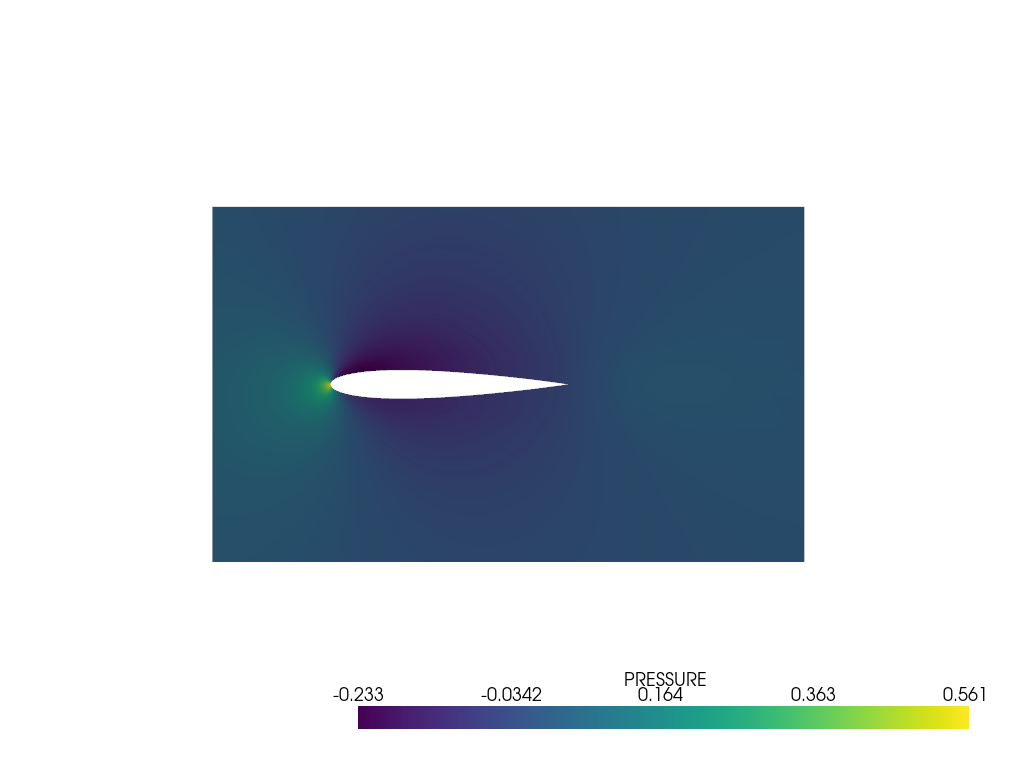

{
  "file": "/tmp/kratos-mcp-naca-1ucxfwdf/vtk_output/FluidModelPart_0_40.vtk",
  "variable": "PRESSURE",
  "component": null,
  "camera": "xy",
  "warp_by": null,
  "warp_factor": 1.0,
  "window_size": [
    1024,
    768
  ],
  "crop_bounds": [
    -0.5,
    2.0,
    -0.75,
    0.75
  ],
  "image_path": "/tmp/kratos-mcp-naca-1ucxfwdf/vtk_output/FluidModelPart_0_40_PRESSURE.png",
  "data_range": [
    -0.23273323476314545,
    0.5614904165267944
  ]
}


{'file': '/tmp/kratos-mcp-naca-1ucxfwdf/vtk_output/FluidModelPart_0_40.vtk',
 'variable': 'PRESSURE',
 'component': None,
 'camera': 'xy',
 'warp_by': None,
 'warp_factor': 1.0,
 'window_size': [1024, 768],
 'crop_bounds': [-0.5, 2.0, -0.75, 0.75],
 'image_path': '/tmp/kratos-mcp-naca-1ucxfwdf/vtk_output/FluidModelPart_0_40_PRESSURE.png',
 'data_range': [-0.23273323476314545, 0.5614904165267944]}

In [29]:
await call(
    "results_render",
    file=vtk_file, variable="PRESSURE", camera="xy", show_edges=False,
    crop_bounds=[-0.5, 2.0, -0.75, 0.75],
)

The stagnation point (high pressure, bright) at the leading edge and the low-pressure region developing over the front of the upper surface are the classic lift-generating pressure signature, even at this modest angle of attack and Reynolds number.

Animate the pressure field settling into its quasi-steady state. The first several steps have a large impulsive-start pressure transient (seen in section 8's `results_convergence` residuals too) that would wash out the color range for the rest of the animation, so this starts from step 10 and takes every other frame after that.

In [30]:
import re

frames = sorted((workdir / "vtk_output").glob("*.vtk"),
                 key=lambda p: int(re.findall(r"\d+", p.stem)[-1]))
settled = [f for f in frames if int(re.findall(r"\d+", f.stem)[-1]) >= 10][::2]
gif_frames_dir = workdir / "vtk_output_gif"
gif_frames_dir.mkdir(exist_ok=True)
for f in settled:
    shutil.copy(f, gif_frames_dir / f.name)
first_step = int(re.findall(r"\d+", settled[0].stem)[-1])
last_step = int(re.findall(r"\d+", settled[-1].stem)[-1])
print(f"{len(frames)} steps simulated, {len(settled)} used for the GIF "
      f"(steps {first_step} to {last_step})")

40 steps simulated, 16 used for the GIF (steps 10 to 40)


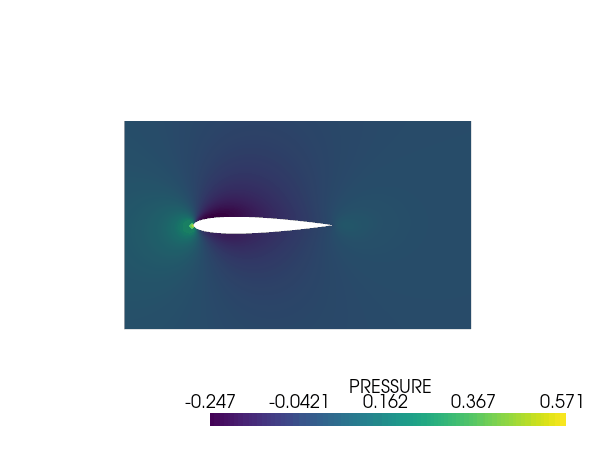

{
  "files": "/tmp/kratos-mcp-naca-1ucxfwdf/vtk_output_gif",
  "variable": "PRESSURE",
  "component": null,
  "camera": "xy",
  "warp_by": null,
  "warp_factor": 1.0,
  "window_size": [
    600,
    450
  ],
  "crop_bounds": [
    -0.5,
    2.0,
    -0.75,
    0.75
  ],
  "gif_path": "/tmp/kratos-mcp-naca-1ucxfwdf/vtk_output_gif/FluidModelPart_PRESSURE.gif",
  "num_frames": 16,
  "fps": 5,
  "data_range": [
    -0.24653194844722748,
    0.5710585117340088
  ]
}


{'files': '/tmp/kratos-mcp-naca-1ucxfwdf/vtk_output_gif',
 'variable': 'PRESSURE',
 'component': None,
 'camera': 'xy',
 'warp_by': None,
 'warp_factor': 1.0,
 'window_size': [600, 450],
 'crop_bounds': [-0.5, 2.0, -0.75, 0.75],
 'gif_path': '/tmp/kratos-mcp-naca-1ucxfwdf/vtk_output_gif/FluidModelPart_PRESSURE.gif',
 'num_frames': 16,
 'fps': 5,
 'data_range': [-0.24653194844722748, 0.5710585117340088]}

In [31]:
await call(
    "results_animate",
    files=str(gif_frames_dir), variable="PRESSURE", camera="xy", show_edges=False,
    crop_bounds=[-0.5, 2.0, -0.75, 0.75], fps=5, window_size=[600, 450],
)

## New capabilities: process schemas, presets, explain & Flowgraph interop

These tools were added after this walkthrough was first written. `kratos_get_process_defaults` recovers a process' parameters by parsing Kratos source; `list_material_presets` offers ready-made materials; `explain_project_parameters` summarises any case; and the Flowgraph tools convert a case to/from the visual node editor, losslessly.

In [32]:
await call("kratos_get_process_defaults", python_module="assign_scalar_variable_process")

{
  "python_module": "assign_scalar_variable_process",
  "default_settings": {
    "help": "This process sets a given scalar value for a certain variable in all the nodes of a submodelpart",
    "model_part_name": "please_specify_model_part_name",
    "variable_name": "SPECIFY_VARIABLE_NAME",
    "interval": [
      0.0,
      1e+30
    ],
    "constrained": true,
    "value": {},
    "local_axes": {}
  },
  "param_types": {
    "help": "string",
    "model_part_name": "string",
    "variable_name": "string",
    "interval": "array",
    "constrained": "bool",
    "value": "json",
    "local_axes": "json"
  },
  "input_model_parts": [
    "model_part_name"
  ],
  "output_params": {
    "variable_name": "SPECIFY_VARIABLE_NAME",
    "interval": [
      0.0,
      1e+30
    ],
    "constrained": true,
    "value": {},
    "local_axes": {}
  },
  "help": "This process sets a given scalar value for a certain variable in all the nodes of a submodelpart"
}


{'python_module': 'assign_scalar_variable_process',
 'default_settings': {'help': 'This process sets a given scalar value for a certain variable in all the nodes of a submodelpart',
  'model_part_name': 'please_specify_model_part_name',
  'variable_name': 'SPECIFY_VARIABLE_NAME',
  'interval': [0.0, 1e+30],
  'constrained': True,
  'value': {},
  'local_axes': {}},
 'param_types': {'help': 'string',
  'model_part_name': 'string',
  'variable_name': 'string',
  'interval': 'array',
  'constrained': 'bool',
  'value': 'json',
  'local_axes': 'json'},
 'input_model_parts': ['model_part_name'],
 'output_params': {'variable_name': 'SPECIFY_VARIABLE_NAME',
  'interval': [0.0, 1e+30],
  'constrained': True,
  'value': {},
  'local_axes': {}},
 'help': 'This process sets a given scalar value for a certain variable in all the nodes of a submodelpart'}

In [33]:
await call("list_material_presets")

{
  "linear_elastic_3d": {
    "description": "Linear elastic isotropic solid (3D). Small-strain Hooke's law.",
    "application": "StructuralMechanicsApplication",
    "constitutive_law": "LinearElastic3DLaw",
    "variables": {
      "YOUNG_MODULUS": 210000000000.0,
      "POISSON_RATIO": 0.3,
      "DENSITY": 7850.0
    }
  },
  "linear_elastic_plane_strain": {
    "description": "Linear elastic isotropic solid, 2D plane-strain assumption.",
    "application": "StructuralMechanicsApplication",
    "constitutive_law": "LinearElasticPlaneStrain2DLaw",
    "variables": {
      "YOUNG_MODULUS": 210000000000.0,
      "POISSON_RATIO": 0.3,
      "DENSITY": 7850.0
    }
  },
  "linear_elastic_plane_stress": {
    "description": "Linear elastic isotropic solid, 2D plane-stress assumption (thin sheets).",
    "application": "StructuralMechanicsApplication",
    "constitutive_law": "LinearElasticPlaneStress2DLaw",
    "variables": {
      "YOUNG_MODULUS": 210000000000.0,
      "POISSON_RATIO"

{'linear_elastic_3d': {'description': "Linear elastic isotropic solid (3D). Small-strain Hooke's law.",
  'application': 'StructuralMechanicsApplication',
  'constitutive_law': 'LinearElastic3DLaw',
  'variables': {'YOUNG_MODULUS': 210000000000.0,
   'POISSON_RATIO': 0.3,
   'DENSITY': 7850.0}},
 'linear_elastic_plane_strain': {'description': 'Linear elastic isotropic solid, 2D plane-strain assumption.',
  'application': 'StructuralMechanicsApplication',
  'constitutive_law': 'LinearElasticPlaneStrain2DLaw',
  'variables': {'YOUNG_MODULUS': 210000000000.0,
   'POISSON_RATIO': 0.3,
   'DENSITY': 7850.0}},
 'linear_elastic_plane_stress': {'description': 'Linear elastic isotropic solid, 2D plane-stress assumption (thin sheets).',
  'application': 'StructuralMechanicsApplication',
  'constitutive_law': 'LinearElasticPlaneStress2DLaw',
  'variables': {'YOUNG_MODULUS': 210000000000.0,
   'POISSON_RATIO': 0.3,
   'DENSITY': 7850.0}},
 'small_strain_plasticity_von_mises_3d': {'description': 'S

In [34]:
await call("explain_project_parameters", parameters_file=str(workdir / "ProjectParameters.json"))

{
  "kind": "single_stage",
  "analysis_type": "fluid",
  "analysis_stage": "KratosMultiphysics.FluidDynamicsApplication.fluid_dynamics_analysis",
  "problem_name": "naca_airfoil",
  "parallel_type": "OpenMP",
  "start_time": 0.0,
  "end_time": 2.0,
  "solver": {
    "solver_type": "Monolithic",
    "model_part_name": "FluidModelPart",
    "domain_size": 2
  },
  "linear_solver": {
    "solver_type": "LinearSolversApplication.sparse_lu"
  },
  "model_import": {
    "input_type": "mdpa",
    "input_filename": "mesh"
  },
  "materials": {
    "materials_filename": "Materials.json"
  },
  "processes": [
    {
      "list": "boundary_conditions_process_list",
      "python_module": "assign_vector_variable_process",
      "kratos_module": "KratosMultiphysics",
      "process_name": "AssignVectorVariableProcess",
      "model_parts": [
        "FluidModelPart.AutomaticInlet2D_Left"
      ]
    },
    {
      "list": "boundary_conditions_process_list",
      "python_module": "assign_scalar_va

{'kind': 'single_stage',
 'analysis_type': 'fluid',
 'analysis_stage': 'KratosMultiphysics.FluidDynamicsApplication.fluid_dynamics_analysis',
 'problem_name': 'naca_airfoil',
 'parallel_type': 'OpenMP',
 'start_time': 0.0,
 'end_time': 2.0,
 'solver': {'solver_type': 'Monolithic',
  'model_part_name': 'FluidModelPart',
  'domain_size': 2},
 'linear_solver': {'solver_type': 'LinearSolversApplication.sparse_lu'},
 'model_import': {'input_type': 'mdpa', 'input_filename': 'mesh'},
 'materials': {'materials_filename': 'Materials.json'},
 'processes': [{'list': 'boundary_conditions_process_list',
   'python_module': 'assign_vector_variable_process',
   'kratos_module': 'KratosMultiphysics',
   'process_name': 'AssignVectorVariableProcess',
   'model_parts': ['FluidModelPart.AutomaticInlet2D_Left']},
  {'list': 'boundary_conditions_process_list',
   'python_module': 'assign_scalar_variable_process',
   'kratos_module': 'KratosMultiphysics',
   'process_name': 'AssignScalarVariableProcess',
  

In [35]:
await call("export_case_to_flowgraph",
           parameters_file=str(workdir / "ProjectParameters.json"),
           output_file=str(workdir / "graph.json"))
back = await call("import_flowgraph_to_case",
                  graph_file=str(workdir / "graph.json"))
original = json.loads((workdir / "ProjectParameters.json").read_text())
print("Flowgraph round-trip reproduces the original exactly:",
      json.dumps(original, sort_keys=True) == json.dumps(back["parameters"], sort_keys=True))

{
  "graph": {
    "last_node_id": 11,
    "last_link_id": 10,
    "nodes": [
      {
        "id": 1,
        "type": "Solvers/Fluid dynamics/NavierStokesSolverMonolithic",
        "pos": [
          260,
          100
        ],
        "size": [
          220,
          100
        ],
        "flags": {},
        "mode": 0,
        "inputs": [],
        "outputs": [],
        "properties": {
          "_role": "solver_settings",
          "_analysis_stage": "KratosMultiphysics.FluidDynamicsApplication.fluid_dynamics_analysis",
          "_process_lists": [
            "initial_conditions_process_list",
            "boundary_conditions_process_list",
            "gravity",
            "auxiliar_process_list"
          ],
          "_output_process_lists": [
            "gid_output",
            "vtk_output"
          ],
          "_fragment": {
            "solver_type": "Monolithic",
            "model_part_name": "FluidModelPart",
            "domain_size": 2,
            "echo_lev

## Cleanup

Close the client session (which stops the server subprocess). The case
directory is left on disk — `workdir`, printed above — open its
`vtk_output/` in ParaView if you want to look at the raw results yourself.

In [36]:
_stop_event.set()      # wake the lifecycle task up ...
await _server_task     # ... and let it exit its own AsyncExitStack from the task that opened it
print("session closed, server subprocess terminated")
print(workdir)

session closed, server subprocess terminated
/tmp/kratos-mcp-naca-1ucxfwdf
